<a href="https://colab.research.google.com/github/Thujaina/ECG-Classification---MobileNet/blob/main/brier_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, DepthwiseConv1D, MaxPooling1D
from keras.layers import Dense, BatchNormalization, GlobalAveragePooling1D
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount('/content/drive')

import warnings
warnings.filterwarnings("ignore")

Mounted at /content/drive


In [4]:
TRAIN_PATH = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/datasets/ECG/mitbih_train.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (87554, 188)
Test shape: (87554, 188)


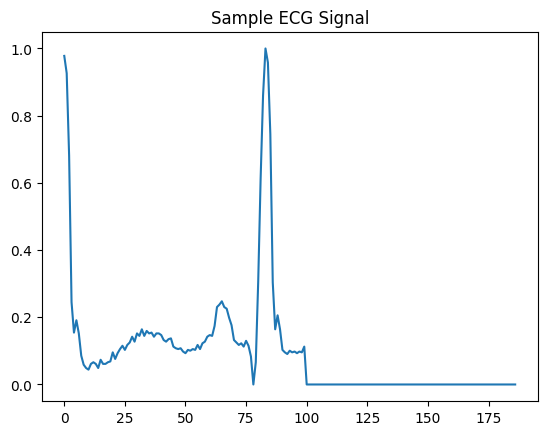

In [5]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

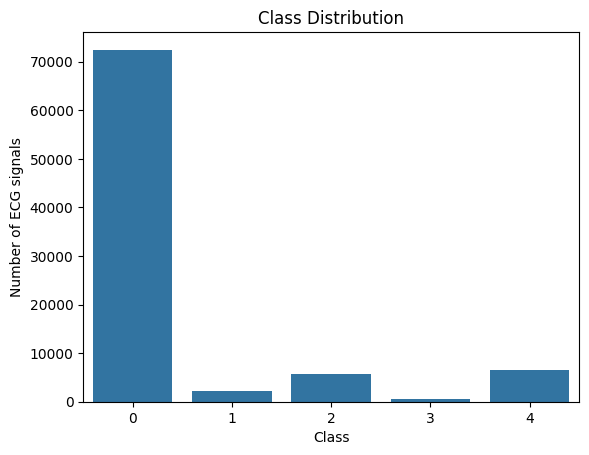

In [6]:
counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)

plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

In [7]:
print("Missing values train:",train.isna().sum().sum())
print("Missing values test:",test.isna().sum().sum())

Missing values train: 0
Missing values test: 0


In [8]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [9]:
smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [10]:
y_res_cat = to_categorical(y_res, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

In [11]:
X_res = np.array(X_res).reshape(-1,187,1)
X_test = np.array(X_test).reshape(-1,187,1)

In [12]:
def brier_score_loss(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    return tf.reduce_mean(tf.reduce_sum(tf.square(y_true - y_pred), axis=1))


def mobilenet_ecg():

    model = Sequential()

    model.add(Conv1D(32,3,activation='relu',input_shape=(187,1)))
    model.add(BatchNormalization())

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(64,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(128,1,activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))

    model.add(DepthwiseConv1D(3,activation='relu'))
    model.add(Conv1D(256,1,activation='relu'))
    model.add(BatchNormalization())

    model.add(GlobalAveragePooling1D())

    model.add(Dense(128,activation='relu'))
    model.add(Dense(5,activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=brier_score_loss,
        metrics=['accuracy']
    )

    return model

In [14]:
kfold = KFold(n_splits=3, shuffle=True, random_state=42)

cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = mobilenet_ecg()

    model.fit(
        X_tr,
        y_tr,
        epochs=5,
        batch_size=64,
        verbose=1
    )

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    cv_accuracies.append(acc)

print("\nCross-validation accuracies:", cv_accuracies)
print("Mean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 355s 92ms/step - accuracy: 0.9384 - loss: 0.0939
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 342s 81ms/step - accuracy: 0.9723 - loss: 0.0437
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 310s 82ms/step - accuracy: 0.9800 - loss: 0.0316
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 309s 82ms/step - accuracy: 0.9839 - loss: 0.0256
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 311s 82ms/step - accuracy: 0.9865 - loss: 0.0217

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 312s 82ms/step - accuracy: 0.9409 - loss: 0.0891
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 307s 81ms/step - accuracy: 0.9752 - loss: 0.0389
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 308s 81ms/step - accuracy: 0.9826 - loss: 0.0275
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 320s 81ms/step - accuracy: 0.9855 - loss: 0.0228
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 323s 81ms/step - accuracy: 0.9874 - loss: 0.0199

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 315s 82ms/step - accuracy: 0.9380 -

In [15]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [16]:
model = mobilenet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final,y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 439s 96ms/step - accuracy: 0.9430 - loss: 0.0872 - val_accuracy: 0.9261 - val_loss: 0.1100
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 414s 89ms/step - accuracy: 0.9746 - loss: 0.0401 - val_accuracy: 0.9694 - val_loss: 0.0472
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 400s 88ms/step - accuracy: 0.9814 - loss: 0.0295 - val_accuracy: 0.7030 - val_loss: 0.5062
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 411s 91ms/step - accuracy: 0.9859 - loss: 0.0225 - val_accuracy: 0.6944 - val_loss: 0.5086
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 402s 89ms/step - accuracy: 0.9883 - loss: 0.0190 - val_accuracy: 0.9782 - val_loss: 0.0339
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 389s 86ms/step - accuracy: 0.9898 - loss: 0.0164 - val_accuracy: 0.6530 - val_loss: 0.6003
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 390s 86ms/step - accuracy: 0.9909 - loss: 0.0145 - val_accuracy: 0.9864 - val_loss: 0.0216
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 388s 86ms/step - accuracy: 

In [17]:
y_val_pred = np.argmax(model.predict(X_val_final), axis=1)
y_val_true = np.argmax(y_val_final, axis=1)

val_mcc = matthews_corrcoef(y_val_true, y_val_pred)

print("Validation MCC:", val_mcc)

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step
Validation MCC: 0.7571881587500652


Final Training Accuracy: 0.9932421445846558
Final Validation Accuracy: 0.7855280041694641


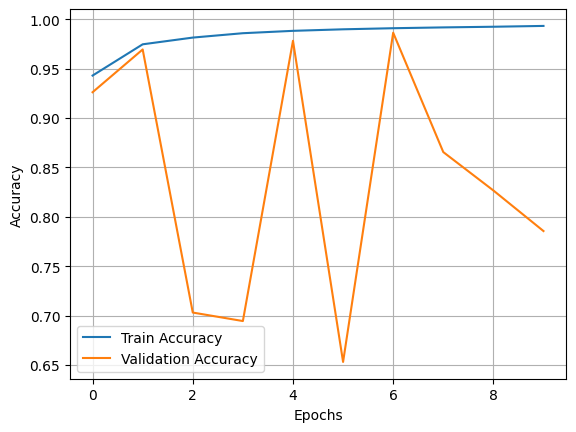

In [18]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

Final Training Loss: 0.01088552363216877
Final Validation Loss: 0.3660179078578949


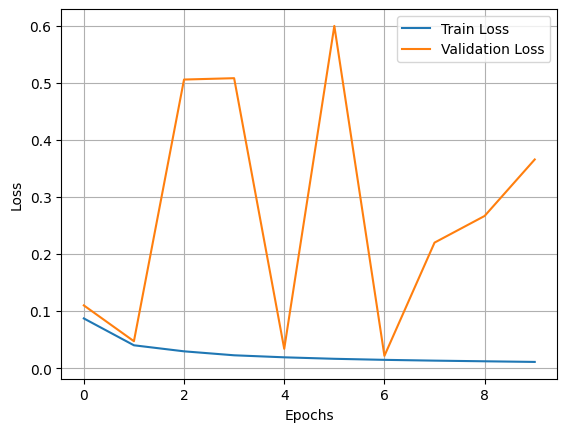

In [19]:
print("Final Training Loss:", history.history['loss'][-1])
print("Final Validation Loss:", history.history['val_loss'][-1])

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

Test Loss: 0.05708036571741104
Test Accuracy: 0.9655983448028564
2737/2737 ━━━━━━━━━━━━━━━━━━━━ 31s 11ms/step
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98     72471
         1.0       0.65      0.88      0.75      2223
         2.0       0.96      0.87      0.92      5788
         3.0       1.00      0.01      0.02       641
         4.0       1.00      0.94      0.97      6431

    accuracy                           0.97     87554
   macro avg       0.92      0.74      0.73     87554
weighted avg       0.97      0.97      0.96     87554



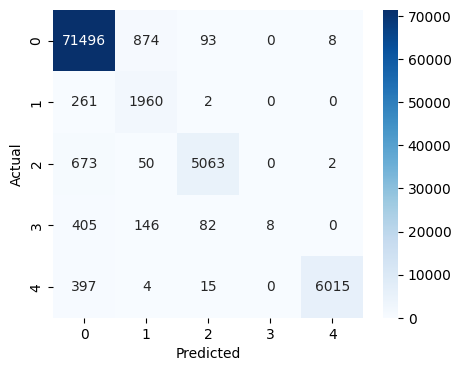

In [21]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()